**ENEE 408I: Lab 3**

Group 6

Martin Haralanov, Jaime Gomez, Nick Betters, Mark Phelps

**`3.1: Part A - Analyzing Audio Signal and Downsampling`**

1. Switch to your virtual environment

2.  Read the wav file “human_voice.wav” and write down its original sampling frequency.

In [2]:
from scipy.io import wavfile

fs, audio = wavfile.read('human_voice.wav')

print("Original sampling frequency:", fs, "Hz")

Original sampling frequency: 48000 Hz


3. Plot the signal using matplotlib.



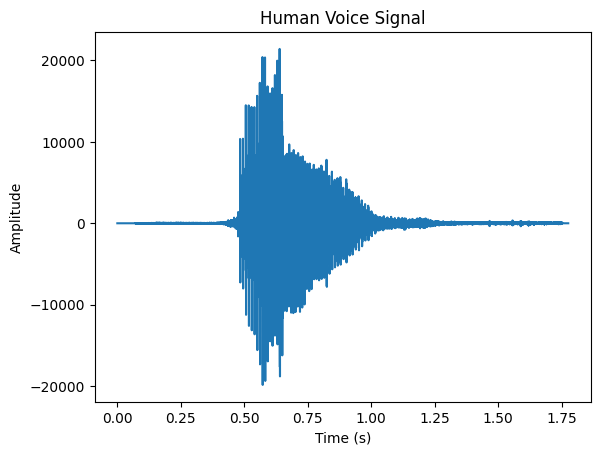

In [3]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(audio)) / fs

plt.plot(time, audio)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Human Voice Signal")
plt.show()

4. Downsample the audio file to 8kHz without using inbuilt functions.

In [ ]:
target_fs = 8000

# Calc downsampling ratio
ratio = fs // target_fs

# downsample by taking every nth sample
audio_downsampled = audio[::ratio]

print("Original sampling frequency:", fs, "Hz")
print("New sampling frequency:", target_fs, "Hz")

Original sampling frequency: 48000 Hz
New sampling frequency: 8000 Hz


5. How many audio samples were obtained after downsampling?

In [ ]:
print("Number of samples BEFORE downsampling:", len(audio))
print("Number of samples AFTER downsampling:", len(audio_downsampled))

Number of samples BEFORE downsampling: 85248
Number of samples AFTER downsampling: 14208


6. Plot the downsampled signal using matplotlib.

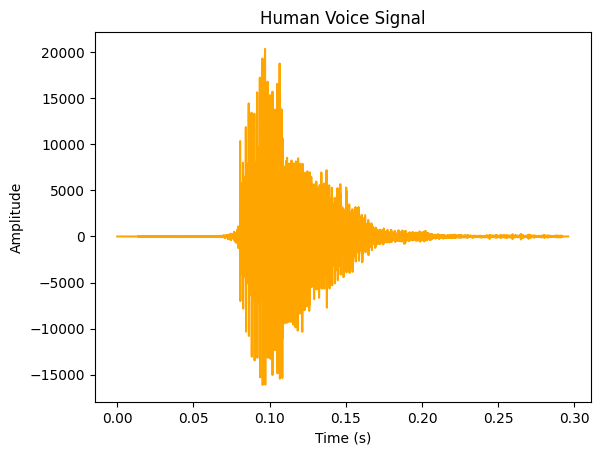

In [ ]:
time = np.arange(len(audio_downsampled)) / fs

plt.plot(time, audio_downsampled, color='orange')
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Human Voice Signal")
plt.show()

7. Observe a section of the audio signal corresponding to the same time period (hint: think of the
sampling ratio and select two starting and ending points). What differences do you notice?

The downsampled signal has fewer points, but still has roughly the same overall shape. At 8 kHz, it has 1/6 as many samples as the original 48 kHz signal.

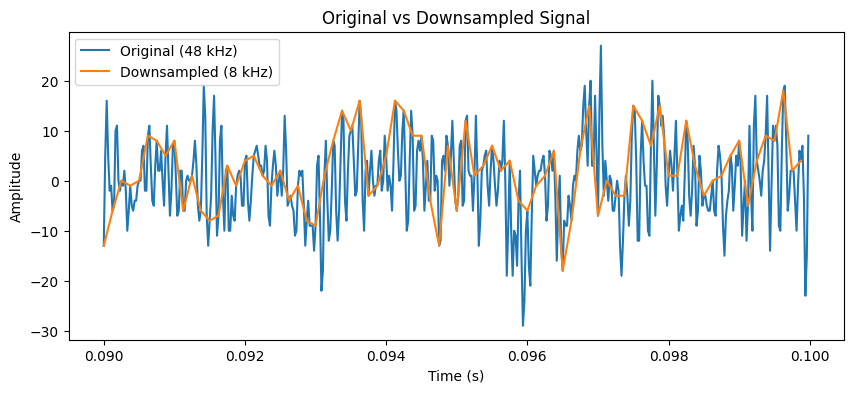

In [ ]:
# Same time period for both signals
start_time = 0.09
end_time = 0.10

# Original signal
start_original = int(start_time * fs)
end_original = int(end_time * fs)

# Downsampled signal
start_down = int(start_time * target_fs)
end_down = int(end_time * target_fs)

plt.figure(figsize=(10, 4))

plt.plot(np.arange(start_original, end_original) / fs, audio[start_original:end_original], label="Original (48 kHz)")

plt.plot(np.arange(start_down, end_down) / target_fs, audio_downsampled[start_down:end_down], label="Downsampled (8 kHz)")

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("Original vs Downsampled Signal")
plt.legend()
plt.show()

**3.2: Part B - RMS, Cross-Correlation, and Sound Localization**

In [4]:
from scipy.io import wavfile
import numpy as np

fs1, M1 = wavfile.read('M1.wav')
fs2, M2 = wavfile.read('M2.wav')
fs3, M3 = wavfile.read('M3.wav')

M1 = M1.astype(float)
M2 = M2.astype(float)
M3 = M3.astype(float)
M1_RMS = np.sqrt(np.mean(M1**2))
M2_RMS = np.sqrt(np.mean(M2**2))
M3_RMS = np.sqrt(np.mean(M3**2))
print(f"RMS of M1: {M1_RMS}")
print(f"RMS of M2: {M2_RMS}")
print(f"RMS of M3: {M3_RMS}")

RMS of M1: 7383.243593119038
RMS of M2: 5906.3835785917545
RMS of M3: 7383.243593119038


M1 has a higher RMS than M2, so the amplitude of the audio must be higher, thus M1 is closer.

In [ ]:
def cross_corr(x, y):

    nx = len(x)
    ny = len(y)

    out_len = nx + ny - 1
    out = np.zeros(out_len)
    x_padded = np.pad(x, (ny - 1, ny - 1), mode='constant', constant_values=0)
    for i in range(out_len):
        x_slice = x_padded[i : i + ny]
        out[i] = np.sum(x_slice * y)

    return out

cc = cross_corr(M1, M2)
max_val = np.max(cc)
max_index = np.where(cc == max_val)
delay = max_index[0]/fs1
print(f"Delay between M1 and M2 (in seconds): {delay}")

Delay between M1 and M2: [2.999375]


Part 3.2.4

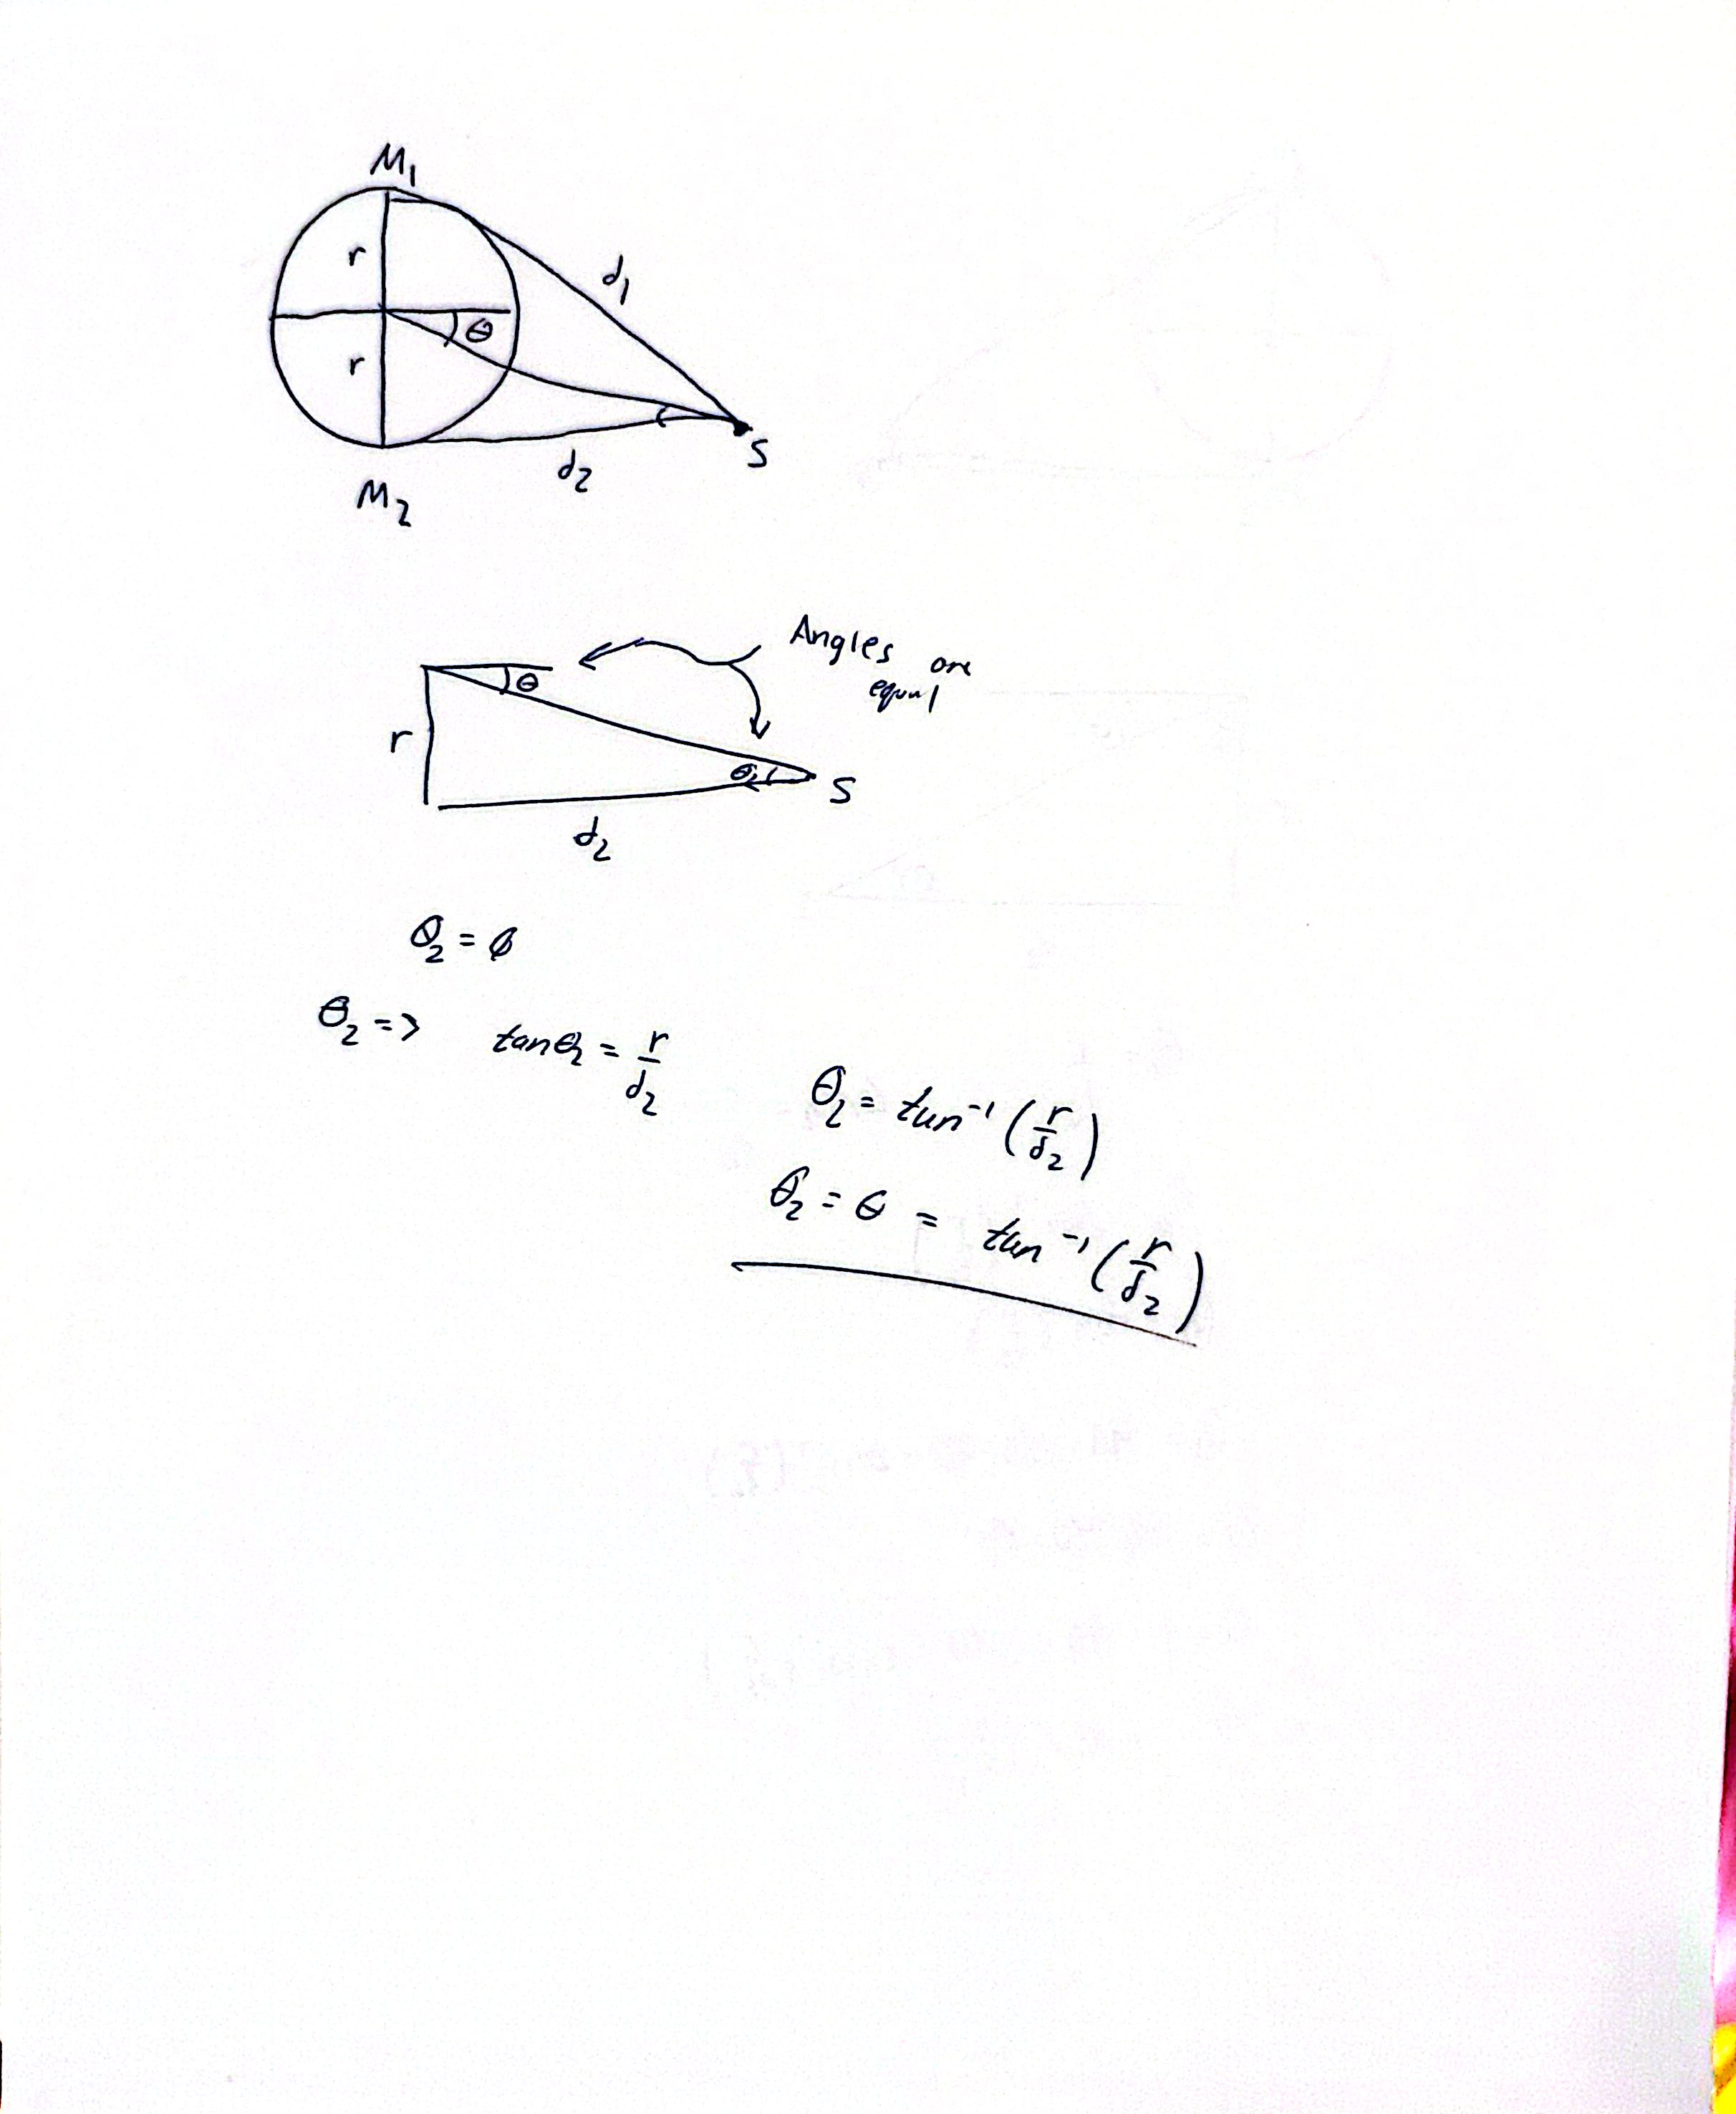

**3.3: Part C - Frequency Spectrum and Filtering**

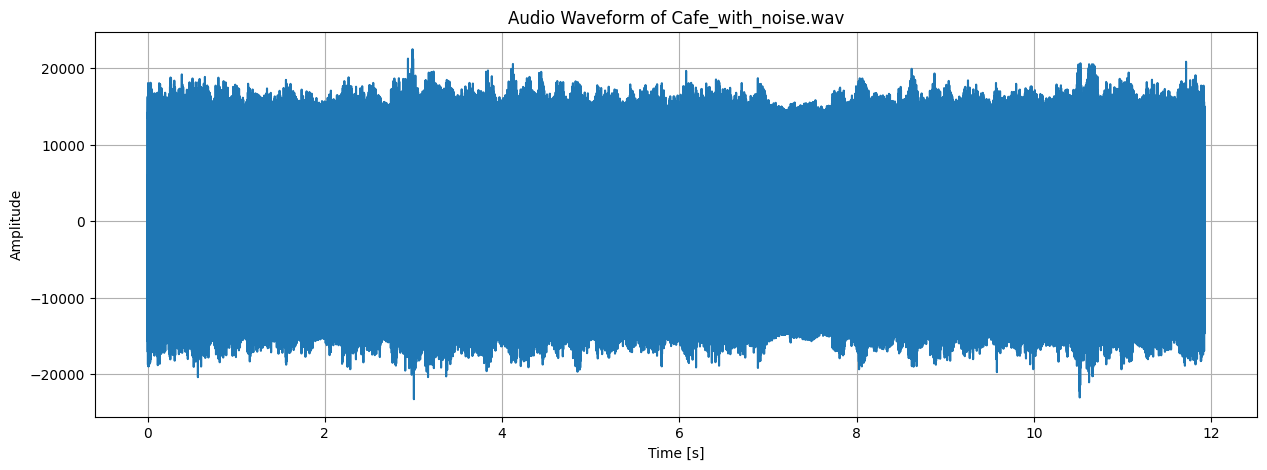

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

audio_file_name = 
full_audio_path = '/content/drive/MyDrive/ENEE408I/Lab 3/' + audio_file_name
samplerate, data = wavfile.read('Cafe_with_noise.wav')

time = np.linspace(0., data.shape[0] / samplerate, data.shape[0])

plt.figure(figsize=(15, 5))
plt.plot(time, data)
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.title(f"Audio Waveform of {audio_file_name}")
plt.grid(True)
plt.show()

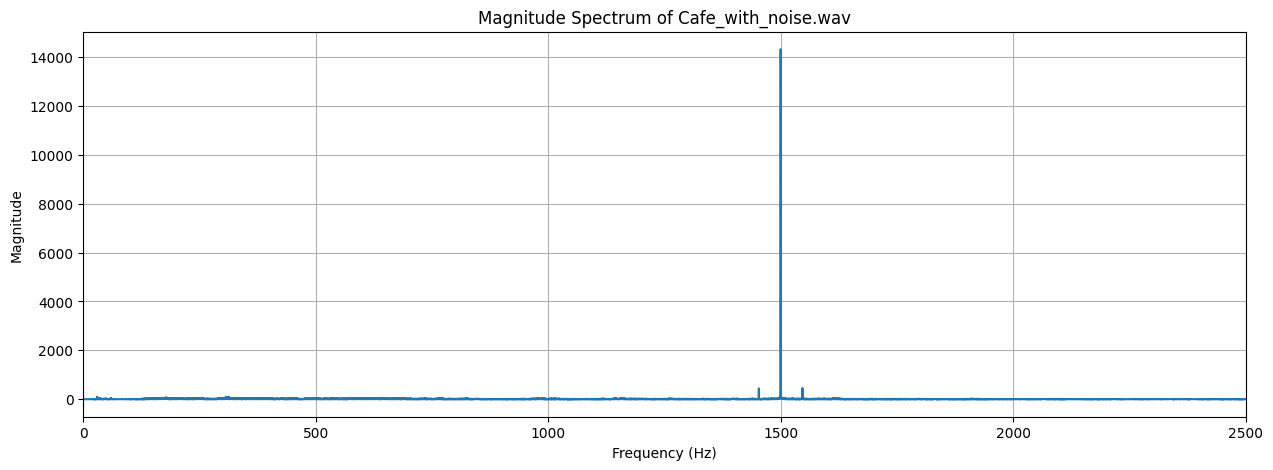

In [ ]:
from scipy.fft import fft, fftfreq

data_float = data.astype(float)

N = len(data_float)
T = 1.0 / samplerate
yf = fft(data_float)
xf = fftfreq(N, T)[:N//2]

plt.figure(figsize=(15, 5))
plt.plot(xf, 2.0/N * np.abs(yf[0:N//2]))
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.title(f"Magnitude Spectrum of {audio_file_name}")
plt.grid(True)
plt.xlim(0, 2500)
plt.show()

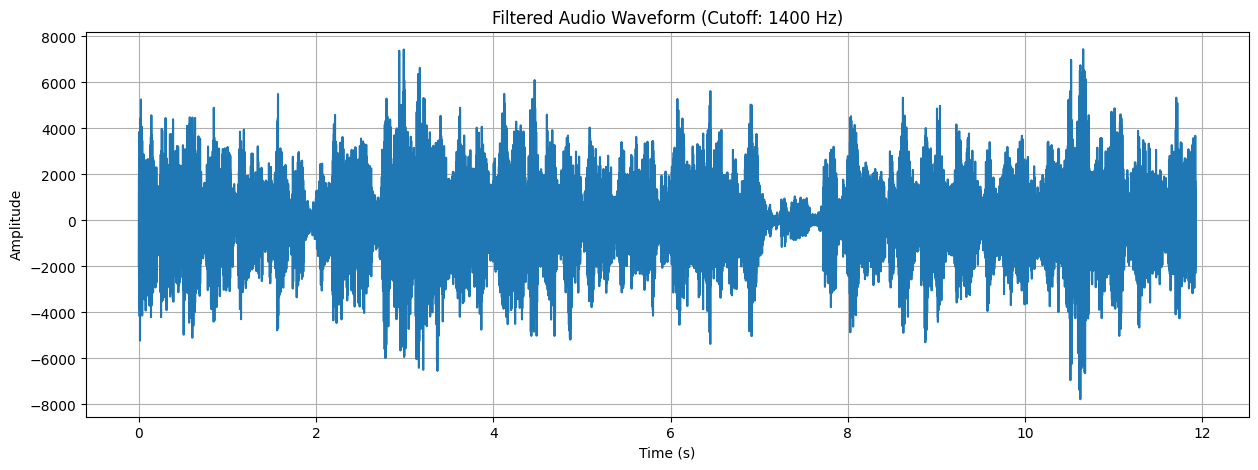

In [ ]:
cutoff_freq = 1400 # Hz
full_xf = fftfreq(N, T)
yf_filtered = yf.copy()
filter_mask = np.abs(full_xf) > cutoff_freq
yf_filtered[filter_mask] = 0
filtered_data_time = np.fft.ifft(yf_filtered)
filtered_data_time = np.real(filtered_data_time).astype(data.dtype)

plt.figure(figsize=(15, 5))
plt.plot(time, filtered_data_time)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Filtered Audio Waveform (Cutoff: {cutoff_freq} Hz)")
plt.grid(True)
plt.show()